Duilio Lucio, Vivian Hu

Spring 2026

CS 343: Neural Networks

Project 2: Multi-layer Perceptrons

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt

# for preprocessing dataset
import preprocess_data

# Set the color style so that Professor Layton can see your plots
plt.show()
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.rcParams.update({'font.size': 20})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

def plot_cross_entropy_loss(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Training mini-batch')
    plt.ylabel('Loss (cross-entropy)')
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load in data

### a. STL-10

Run your function to load in the preprocessed STL-10 data in the following split:

- 3000 training samples
- 750 test samples
- 1000 validation samples
- 250 samples for development

In [25]:
# YOUR CODE HERE
cis_train_all, cis_test_all, cis_x_test, cis_y_test, cis_x_val, cis_y__val, cis_x_dev, cis_y_dev = preprocess_data.load_stl10(n_train_samps=3000, n_test_samps=750, n_valid_samps=1000, n_dev_samps=250)

Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)


### b. Circle in a square

The circle in a square (CIS) dataset is a simple binary classification dataset that is useful for debugging and visualizing what your MLP is learning. Points with (x, y) coordinates inside a circle have class value of 1, points with coordinates outside the circle have class value of 0. Training on the CIS dataset allows us to answer the question: can the MLP learn to discriminate whether a test point falls inside or outside the circle?

#### Todo

- Download the CIS dataset then run the cell below to load in the CIS train (`cis_train.dat`) and test (`cis_test.dat`) sets as numpy arrays.
- Below, make a scatterplot showing the test set data. Color-code samples based on their class. If everything goes well, you should see a...solid, filled in circle inside unit square :)
    - Make the aspect ratio of your x, y plotting axes equal, otherwiwse you might see an ellipse!

In case you're curious about the data format:
- Like usual, each row is a different sample.
- The x-coordinate feature is the 1st column
- The y-coordinate feature is the 2nd column
- The class label (0 or 1) is in the third column.


In [27]:
val_size = 20

cis_train_path = os.path.join('data', 'cis', 'cis_train.dat')
cis_test_path = os.path.join('data', 'cis', 'cis_test.dat')

cis_train_all = np.loadtxt(cis_train_path, delimiter='\t')

# shuffle the data
s_inds = np.arange(len(cis_train_all))
rng = np.random.default_rng(0)
rng.shuffle(s_inds)

cis_train_all = cis_train_all[s_inds]

cis_train_x = cis_train_all[:, :2]
cis_train_y = cis_train_all[:, 2].astype(int)

cis_val_x = cis_train_x[:val_size]
cis_train_x = cis_train_x[val_size:]
cis_val_y = cis_train_y[:val_size]
cis_train_y = cis_train_y[val_size:]

cis_test_all = np.loadtxt(cis_test_path, delimiter='\t')
cis_test_x = cis_test_all[:, :2]
cis_test_y = cis_test_all[:, 2].astype(int)

print ('CIS Train data shape: ', cis_train_x.shape)
print ('CIS Train labels shape: ', cis_train_y.shape)
print ('CIS Validation data shape: ', cis_val_x.shape)
print ('CIS Validation labels shape: ', cis_val_y.shape)
print ('CIS Test data shape: ', cis_test_x.shape)
print ('CIS Test labels shape: ', cis_test_y.shape)

CIS Train data shape:  (80, 2)
CIS Train labels shape:  (80,)
CIS Validation data shape:  (20, 2)
CIS Validation labels shape:  (20,)
CIS Test data shape:  (10000, 2)
CIS Test labels shape:  (10000,)


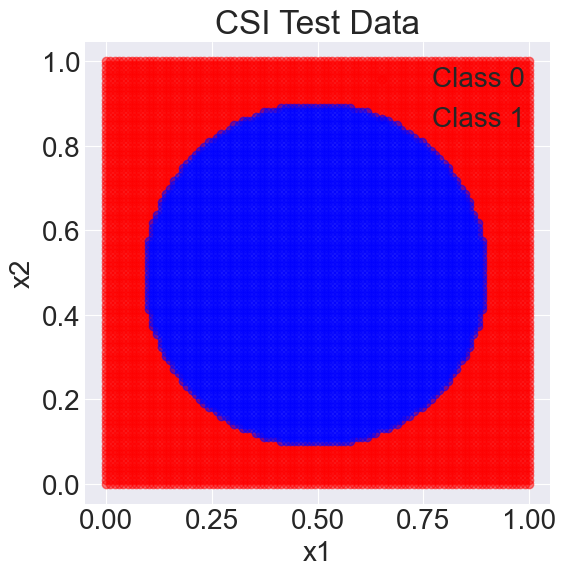

In [28]:
# YOUR CODE HERE

# Scatterplot of Test set data
plt.figure(figsize=(6, 6))
plt.scatter(cis_test_x[cis_test_y == 0, 0], cis_test_x[cis_test_y == 0, 1], color = 'red', label = 'Class 0', alpha = 0.5)
plt.scatter(cis_test_x[cis_test_y == 1, 0], cis_test_x[cis_test_y == 1, 1], color = 'blue', label = 'Class 1', alpha = 0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('CSI Test Data')
plt.legend()
plt.axis('equal') # Ensures aspect ratio is equal to see circle shape
plt.show()

## Task 3: Implement Multilayer Perceptron (MLP) with softmax activation and cross-entropy loss

Now that we've tested the softmax activation function and cross-entropy loss functions in a single-layer net, let's implement the MLP version.

Much of your work on the single layer net will carry over, so go ahead and copy-paste and modify as needed!

#### The structure of our MLP

```
Input layer (X units) ->
Hidden layer (Y units) with Rectified Linear activation (ReLu) ->
Output layer (Z units) with softmax activation
```

### 3a. Implement the following functions in `mlp.py`

- `initialize_wts`
- `accuracy`
- `one_hot`
- `predict`
- `forward`
- `backward`
- `fit`: see note below.

#### Updates to `fit`

Now that you have built and fit several neural networks, let's make a helpful update to the training process: in addition to recording the training loss and accuracy, record the accuracy on the **validation set** after every training epoch. Every `print_every` epochs print out validation accuracy to monitor performance on the validation set. See the `fit` docstring for details.

### 3b. Test key functions with randomly generated data

In [10]:
from mlp import MLP

In [11]:
# Create a dummy net for debugging
num_inputs = 3
num_features = 6
num_hidden_units = 7
num_classes = 5

net = MLP(num_features, num_hidden_units, num_classes)

In [12]:
# Generate random data and classes
rng = np.random.default_rng(0)
test_x = rng.normal(loc=0, scale=100, size=(num_inputs, num_features))
test_y = rng.integers(low=0, high=num_classes-1, size=(num_inputs,))
print(f'Test input shape: {test_x.shape}')
print(f'Test class vector shape: {test_y.shape}')

Test input shape: (3, 6)
Test class vector shape: (3,)


#### Test `initialize_wts`

In [29]:
net.initialize_wts(M=num_features, H=num_hidden_units, C=num_classes, std=0.01, r_seed=0)
print(f'y wt shape is {net.y_wts.shape} and should be (6, 7)')
print(f'y bias shape is {net.y_b.shape} and should be (7,)')
print(f'z wt shape is {net.z_wts.shape} and should be (7, 5)')
print(f'z bias shape is {net.z_b.shape} and should be (5,)')

print(f'1st few y wts are\n{net.y_wts[:,0]}\nand should be\n[ 0.001  0.009 -0.012  0.014 -0.005  0.004]')
print(f'y bias is\n{net.y_b}\nand should be\n[0. 0. 0. 0. 0. 0. 0.]')
print(f'1st few z wts are\n{net.z_wts[:,0]}\nand should be\n[ 0.013  0.02  -0.     0.007  0.017  0.013  0.01 ]')
print(f'z bias is\n{net.z_b}\nand should be\n[0. 0. 0. 0. 0.]')

y wt shape is (6, 7) and should be (6, 7)
y bias shape is (7,) and should be (7,)
z wt shape is (7, 5) and should be (7, 5)
z bias shape is (5,) and should be (5,)
1st few y wts are
[ 0.001  0.009 -0.012  0.014 -0.005  0.004]
and should be
[ 0.001  0.009 -0.012  0.014 -0.005  0.004]
y bias is
[0. 0. 0. 0. 0. 0. 0.]
and should be
[0. 0. 0. 0. 0. 0. 0.]
1st few z wts are
[ 0.013  0.02  -0.     0.007  0.017  0.013  0.01 ]
and should be
[ 0.013  0.02  -0.     0.007  0.017  0.013  0.01 ]
z bias is
[0. 0. 0. 0. 0.]
and should be
[0. 0. 0. 0. 0.]


#### Test the `predict` method

In [16]:
test_y_pred = net.predict(test_x)
print(f'Predicted classes are {test_y_pred} and should be [0 2 0]')

Predicted classes are [0 2 0] and should be [0 2 0]


#### Test the `forward` method focusing on`ReLU`(net act of hidden layer `y`)

In [17]:
_,y_net_act_test,_,_,_ = net.forward(test_x, test_y)

correct_y_act = np.array([[0.   , 0.   , 0.43 , 0.383, 0.826, 0.197, 0.446],
       [0.509, 0.354, 0.199, 0.   , 0.   , 0.   , 2.679],
       [0.189, 1.948, 0.   , 0.   , 0.269, 0.   , 0.   ]])

print(f'Your y activation is\n{y_net_act_test}')
print(f'The correct y activation (ReLU) is\n{correct_y_act}')

Your y activation is
[[0.    0.    0.43  0.383 0.826 0.197 0.446]
 [0.509 0.354 0.199 0.    0.    0.    2.679]
 [0.189 1.948 0.    0.    0.269 0.    0.   ]]
The correct y activation (ReLU) is
[[0.    0.    0.43  0.383 0.826 0.197 0.446]
 [0.509 0.354 0.199 0.    0.    0.    2.679]
 [0.189 1.948 0.    0.    0.269 0.    0.   ]]


#### Test the `forward` method

In [18]:
_,_,_,probs,_ = net.forward(test_x, test_y)

correct_probs = np.array([[0.204, 0.198, 0.199, 0.198, 0.201],
       [0.207, 0.197, 0.209, 0.192, 0.196],
       [0.205, 0.203, 0.201, 0.197, 0.193]])

print(f'Your z activation (class probabilities) is\n{probs}')
print(f'The correct z activation (class probabilities) is\n{correct_probs}')
print(f'The sums for each row (data sample) are {np.sum(probs, axis=1)}.')
print(f'  You should know what should be :)')

Your z activation (class probabilities) is
[[0.204 0.198 0.199 0.198 0.201]
 [0.207 0.197 0.209 0.192 0.196]
 [0.205 0.203 0.201 0.197 0.193]]
The correct z activation (class probabilities) is
[[0.204 0.198 0.199 0.198 0.201]
 [0.207 0.197 0.209 0.192 0.196]
 [0.205 0.203 0.201 0.197 0.193]]
The sums for each row (data sample) are [1. 1. 1.].
  You should know what should be :)


#### Test the `forward` method, focusing on loss

In [19]:
y_in, y_act ,z_in, z_act, loss = net.forward(test_x, test_y)
correct_loss = 1.6017

print(f'Your average loss is\n{loss:.4f}')
print(f'The correct average loss is approx\n{correct_loss}')

Your average loss is
1.6017
The correct average loss is approx
1.6017


#### Test the `forward` method, focusing on regularization

In [20]:
y_in, y_act ,z_in, z_act, loss = net.forward(test_x, test_y, reg=1000)
correct_loss = 5.1296

print(f'Your regularized average loss is\n{loss:.4f}')
print(f'The correct regularized average loss is approx\n{correct_loss}')

Your regularized average loss is
5.1296
The correct regularized average loss is approx
5.1296


#### Test the `backward` method

In [21]:
y_in, y_act ,z_in, z_act, loss = net.forward(test_x, test_y, reg=0.5)
grads = net.backward(test_x, test_y, y_in, y_act ,z_in, z_act, reg=0.5)

print('Your gradient for y_wts is\n', grads[0])
print('Your gradient for y_b is\n', grads[1])
print('Your gradient for z_wts is\n', grads[2])
print('Your gradient for z_b is\n', grads[3])

Your gradient for y_wts is
 [[ 0.028  0.315 -0.272 -0.052 -0.882 -0.049  0.272]
 [-0.012 -0.231 -0.209  0.052 -0.027  0.042  0.262]
 [ 0.041  0.602  0.156 -0.267 -0.689 -0.254 -0.369]
 [ 0.054  0.618  0.272 -0.039 -0.302 -0.046 -0.334]
 [ 0.025  0.364  0.12   0.221  0.01   0.22   0.025]
 [ 0.009  0.082 -0.004 -0.146 -0.244 -0.153 -0.098]]
Your gradient for y_b is
 [-0.    -0.006 -0.002 -0.004 -0.    -0.004 -0.001]
Your gradient for z_wts is
 [[ 0.055 -0.182  0.049  0.043  0.053]
 [ 0.167 -0.603  0.162  0.152  0.142]
 [-0.1   -0.022  0.036  0.043  0.044]
 [-0.098  0.019  0.022  0.023  0.02 ]
 [-0.192 -0.019  0.075  0.071  0.081]
 [-0.046  0.016  0.002  0.013  0.017]
 [ 0.071 -0.69   0.225  0.194  0.201]]
Your gradient for z_b is
 [-0.128 -0.467  0.203  0.196  0.197]


The correct gradients are:

```
Your gradient for y_wts is
 [[ 0.028  0.315 -0.272 -0.052 -0.882 -0.049  0.272]
 [-0.012 -0.231 -0.209  0.052 -0.027  0.042  0.262]
 [ 0.041  0.602  0.156 -0.267 -0.689 -0.254 -0.369]
 [ 0.054  0.618  0.272 -0.039 -0.302 -0.046 -0.334]
 [ 0.025  0.364  0.12   0.221  0.01   0.22   0.025]
 [ 0.009  0.082 -0.004 -0.146 -0.244 -0.153 -0.098]]
Your gradient for y_b is
 [-0.    -0.006 -0.002 -0.004 -0.    -0.004 -0.001]
Your gradient for z_wts is
 [[ 0.055 -0.182  0.049  0.043  0.053]
 [ 0.167 -0.603  0.162  0.152  0.142]
 [-0.1   -0.022  0.036  0.043  0.044]
 [-0.098  0.019  0.022  0.023  0.02 ]
 [-0.192 -0.019  0.075  0.071  0.081]
 [-0.046  0.016  0.002  0.013  0.017]
 [ 0.071 -0.69   0.225  0.194  0.201]]
Your gradient for z_b is
 [-0.128 -0.467  0.203  0.196  0.197]
```

#### Test loss over epoch (1 of 2). 

The below code should generate a curve that rapidly drops to 0 (there might be fluctuations and it might not be monotonic and that's ok)

Your `fit` function should show you print-outs showing:
- Loss and validation accuracy 4 times throughout training.
- 100% accuracy on validation set after around 5 epochs of training.
- You are training on 20 epochs.
- There are 20 iterations.
- There is 1 iteration per epoch.

Here is an example print-out from `fit`:

    Starting to train network...There will be 20 epochs and 20 iterations total, 1 iter/epoch.
    Completed Epoch 0/19. Training loss: 4.55. Training acc:  33.33%. Validation acc:  33.33%.
    Completed Epoch 5/19. Training loss: 0.15. Training acc:  66.67%. Validation acc:  66.67%.
    Completed Epoch 10/19. Training loss: 0.34. Training acc: 100.00%. Validation acc: 100.00%.
    Completed Epoch 15/19. Training loss: 0.16. Training acc: 100.00%. Validation acc: 100.00%.
    Finished training!

Epoch 1/20 | Loss: 5.3681 | Train Acc: 0.3333 | Val Acc: 0.3333

Lengths of each output list:
len(loss_hist)=1, len(acc_train)=1, len(acc_valid)=1
Each should be 20.


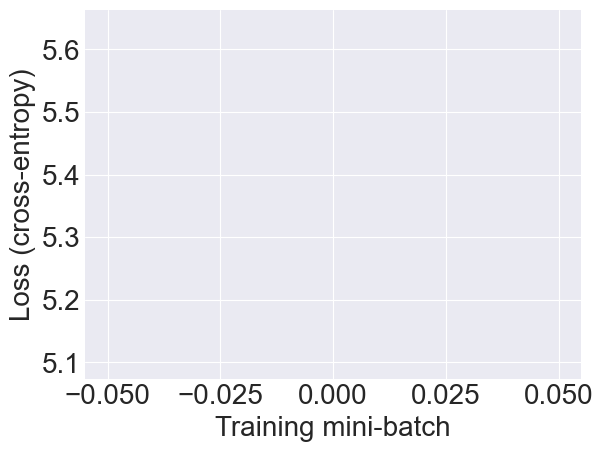

In [22]:
net = MLP(num_features, num_hidden_units, num_classes)
loss_hist, acc_train, acc_valid = net.fit(test_x, test_y, test_x, test_y,
                                          reg=0,
                                          print_every=5,
                                          lr=0.001,
                                          mini_batch_sz=3,
                                          n_epochs=20,
                                          r_seed=1)

print('\nLengths of each output list:')
print(f'{len(loss_hist)=}, {len(acc_train)=}, {len(acc_valid)=}')
print('Each should be 20.')

plot_cross_entropy_loss(loss_hist)

#### Test loss over epoch (2 of 2). 

The below curve should look similar, perhaps a little bumpier.

Your `fit` function should print out:
- Loss and validation accuracy 5 times throughout training.
- 100% accuracy on validation set after around 2 epochs of training.
- You are training on 10 epochs.
- There are 30 iterations.
- There are 3 iterations per epoch.


In [ ]:
net = MLP(num_features, num_hidden_units, num_classes)
loss_hist, acc_train, acc_valid = net.fit(test_x, test_y, test_x, test_y,
                                          reg=0,
                                          print_every=2,
                                          lr=0.001,
                                          mini_batch_sz=1,
                                          n_epochs=10,
                                          r_seed=2)

print('\nLengths of each output list:')
print(f'{len(loss_hist)=}, {len(acc_train)=}, {len(acc_valid)=}')
print('The lengths should be 30, 10, 10.')

plot_cross_entropy_loss(loss_hist)

### 3c. Test MLP with Circle in Square dataset

Before you run your MLP on the STL-10 dataset, test it out on the simpler CIS dataset.

In cells below:
- Train an MLP using the CIS training and validation sets. Configure the MLP with the following non-default hyperparameters:
    - 50 hidden units
    - Learning rate of `0.5`
    - Mini-batch size of `80`
    - `1000` epochs
    - Random seed of `0`
- Plot the loss over training iterations. You should see:
    - A nice drop and plateau in mini-batch training loss (*with a few potentially large fluctuations along the way*).
    - Accuracy on the validation set reach 80-90%.
- Create a scatter plot of the MLP predictions on the CIS test set. Color-code each sample by its class. Make sure your axis aspect ratios are equal.

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

**Question 6**: How do you interpret the circle-in-square scatterplot? Is the MLP doing a good job? 

**Answer 6**:

YOUR ANSWER HERE

**Question 7**: Play with
- number of hidden units
- number of epochs
- batch size

How does each parameter affect the results?

**Answer 7**:

YOUR ANSWER HERE

**Question 8**: Do you think the single-layer net (with softmax) can handle the CIS dataset? Why or why not? (You're invited to try it, maybe as an extension :)

**Answer 8**:

YOUR ANSWER HERE

### 3d. Test on STL-10 dataset, plot performance

Train an MLP on the STL-10 training set with the following non-default hyperparameters:
- 50 hidden units
- Learning rate of 0.1
- Regularization strength of 0.001
- Mini-batch size of 500
- 100 epochs
    
Make two plots:
- Plot the training loss (like usual). *Remember: the units are mini-batches.*
- Plot the training and validation set accuracies (2 curves in one plot — include a legend, title, axis labels, etc.). *Remember: the units are epochs.*

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

### 3e. Questions

**Question 9**: What do the above loss and training and validation accuracy curves suggest about the quality of the hyperparameters used during training?

**Answer 9:**

YOUR ANSWER HERE

### 3f. Optimize on STL-10 dataset with random search

To optimize your MLP hyperparameters on STL-10, try a **random search** rather than a grid search. This means that instead of defining preset *values* that each hyperparameter takes on, define *ranges* (min and max values).

Run your search for some $T$ iterations. On each iteration, randomly assign values to each hyperparameter within their valid ranges.

Just like grid search:
- print out the accuracy and parameter values every time a bout of training yields the **best accuracy** on the **STL-10 validation set**. That way, if you need to stop the search prematurely, you know the current best hyperparameter combination.
- make sure your results from the search are reproducible and you can train a net after the search is over and get the same accuracy.

Consider combinations of the following hyperparameters:
- learning rate
- regularization strength
- number of hidden units
- mini-batch size
- number of epochs (try between `1` and `150`). *Reduce the upper limit if your machine is taking too long to train a net with this many epochs.*

It is up to you to decide what ranges are reasonable to search over for each hyperparameter to achieve the best results.

**Important note:** Like usual, I am not grading based on how long you search. I want to see that you successfully implemented the random search to find progressively better hyperparameters on STL-10. You should be able to improve upon both your softmax net accuracy from last week and the unoptimized MLP from above.

**Tips:**
- Just like with grid search, if you find a cluster of parameters that seems promising, you can revise your search to hone in on that smaller range.
- Turn off print outs from `fit` (adjust `verbose` argument) and only print out things related to your search.
- If you are getting `RuntimeWarning`, your learning rate may be too high.
- Do not shy away from potential `H` values that seem "large" based on what you used with CIS — STL-10 is a much more complex dataset!

In [ ]:
# YOUR CODE HERE

### 3g. Plot STL-10 results with best hyperparameters

Train an MLP with the best hyperparameters that you found from your parameter search and create two plots:
- Training STL-10 loss curve
- Training and validation set STL-10 accuracy curves. **Place the test set accuracy in the plot title.** Your final validation accuracy should match what you obtained from your best network from the random search above.

In [ ]:
# YOUR CODE HERE

### 3i. Visualize learned weights

Run the `plot_weights` function to generate a grid visualization of them.

As with the single layer softmax network, only certain ranges of hyperparameters will produce clear structure in the below images of the hidden unit weights. It is very possible to have a network that is performing well and produces weight visualizes that look like "noise".

In [ ]:
best_y_wts = bestNet.get_y_wts()
best_y_wts = best_y_wts.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)

In [ ]:
def plot_weights(wts, maxRows=25, verbose=0):
    # limit height of figure by number of neurons
    grid_sz = int(maxRows)
    grid_sz = np.minimum(grid_sz, int(np.sqrt(len(wts))))

    if verbose > 0:
        print(f'Showing {grid_sz} rows')

    plt.figure(figsize=(20,20))
    for x in range(grid_sz):
        for y in range(grid_sz):
            lin_ind = np.ravel_multi_index((x, y), dims=(grid_sz, grid_sz))
            plt.subplot(grid_sz, grid_sz, lin_ind+1)
            currImg = wts[lin_ind]
            low, high = np.min(currImg), np.max(currImg)
            currImg = 255*(currImg - low) / (high - low)
            currImg = currImg.astype('uint8')
            plt.imshow(currImg)
            plt.gca().axis('off')
    plt.subplots_adjust(wspace=0.01, hspace=0.01)
    plt.show()

In [ ]:
plot_weights(best_y_wts, verbose=1)

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.** 
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric). 
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

1) There are many other activation functions that could be used for the hidden layer (e.g. Sigmoid, Leaky ReLU, SELU, GELU, Softplus, Mish, etc.). Research one or more, implement them, and compare results with ReLU.

2) Run hyperparameter searches with the nets configured with the different hidden activation functions and explore the extent to which performance improves compare to ReLU.

3) Analyze the differences between training when sampling with replacement (i.e. not every input sample is usually processed on an epoch) and sampling without replacement (e.g. time, accuracy, loss, etc).

4) Investigate how the single layer softmax network does with the CIS dataset. Explain and provide plots showing your results.

5) If you have time to spare (or want to throw more computing power at the STL-10 dataset), process through the Softmax network or MLP and tune hyperparameters with the dataset at its original resolution (96x96 images). Show images of your learned weights. Can you find a training sweet spot where the learned weight visualizations look particularly cool?

6) Implement a multi-class sigmoid classifier (sigmoid activation function in the output layer). I suggest creating another subclass of `SoftmaxLayer` and/or `MLP`. This extension requires some thought. Compare and contrast results achieved by the softmax network.

7) Explore alternative MLP architectures and compare/contrast results and performance with the ones used in the base project. For example, add one or more additional hidden layers.

8)  Explore the effects of batch gradient descent, stochastic gradient descent, and mini-batch gradient descent. Make plots and interpret your results.

9)  Obtain, preprocess, train, and evaluate the performance of `SoftmaxLayer` and/or `MLP` on another dataset with comparable types of image features. MNIST and Fashion MNIST are good ones.

10) Make a fancy coarse-to-fine grid search that automatically "zooms in" on the best hyperparameter combination ranges several times.

11) Because each grid search training session is independent of the others, they can be parallelized. Research parallel computing / multithreading in Python to implement a parallel version of grid search or random search. Characterize the speed gains offered by the parallel search implementation.